<a href="https://colab.research.google.com/github/ShoubithS3/InternSpark-Machine-Learning-Projects/blob/main/MLPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#
# Major Machine Learning Project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load IBM Telco Customer Churn dataset

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (7043, 21)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


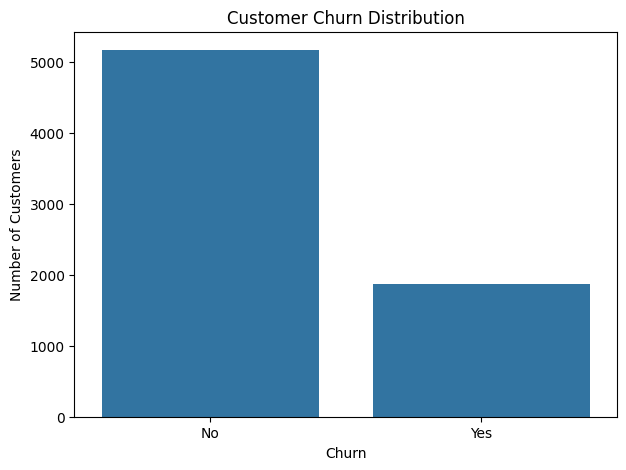

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values("Percentage", ascending=False)

missing_table

,Missing Values,Percentage


In [ ]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges']


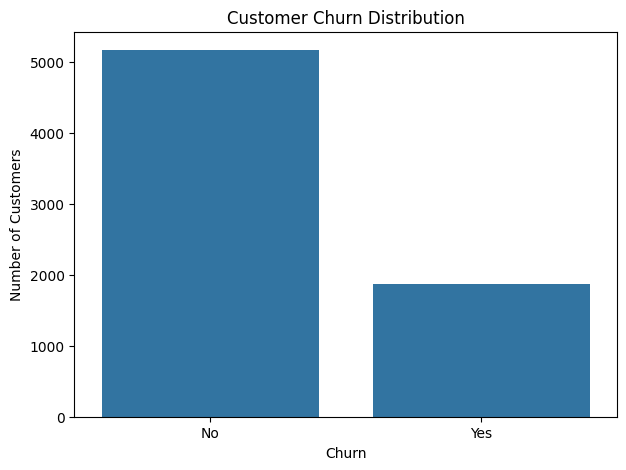

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print("Churn Percentage:")
print(churn_percentage)

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


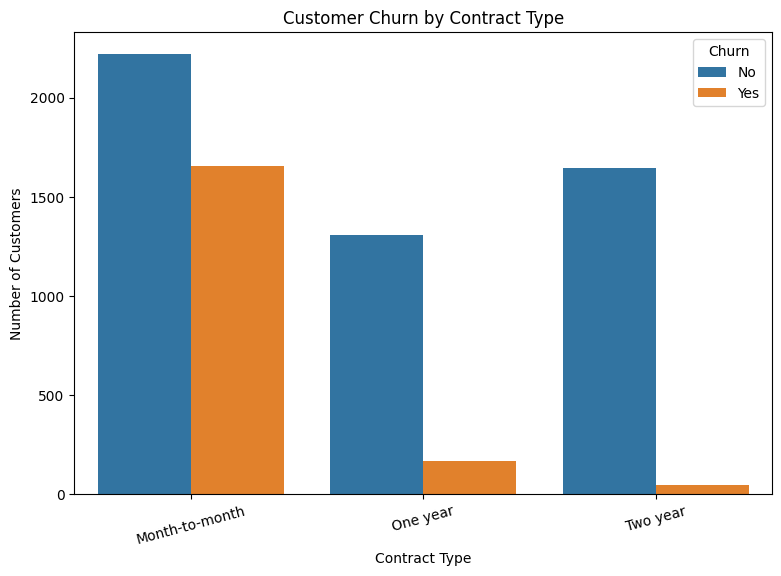

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, x="Contract", hue="Churn")

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)
plt.show()

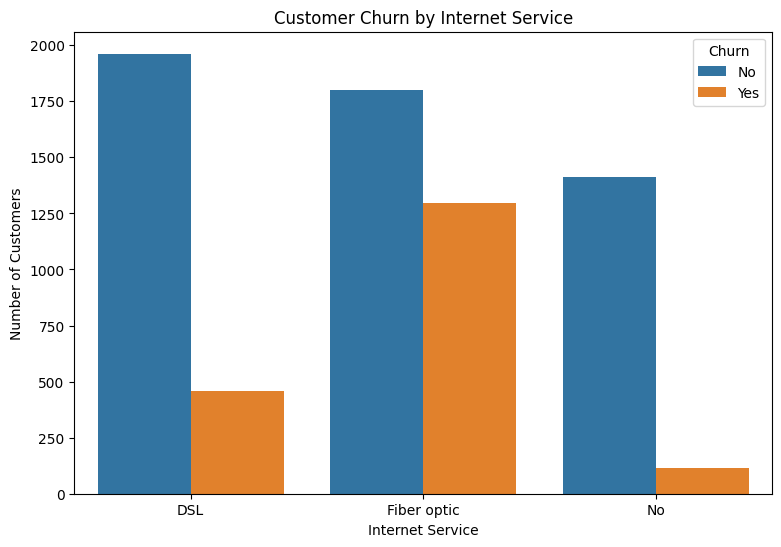

In [ ]:
plt.figure(figsize=(9,6))

sns.countplot(data=df, x="InternetService", hue="Churn")

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

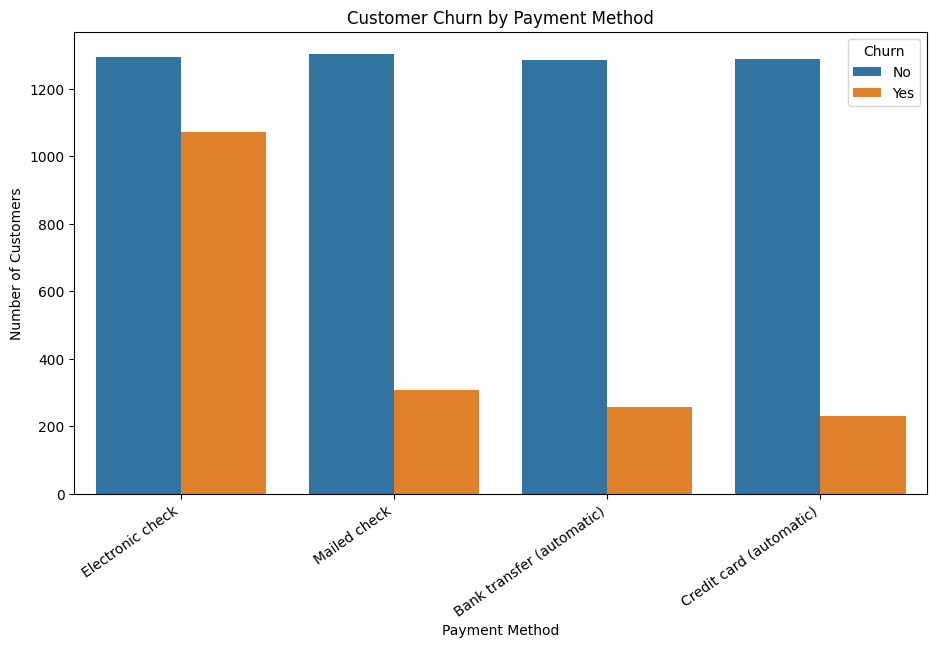

In [ ]:
plt.figure(figsize=(11,6))

sns.countplot(data=df, x="PaymentMethod", hue="Churn")

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=35, ha="right")
plt.show()

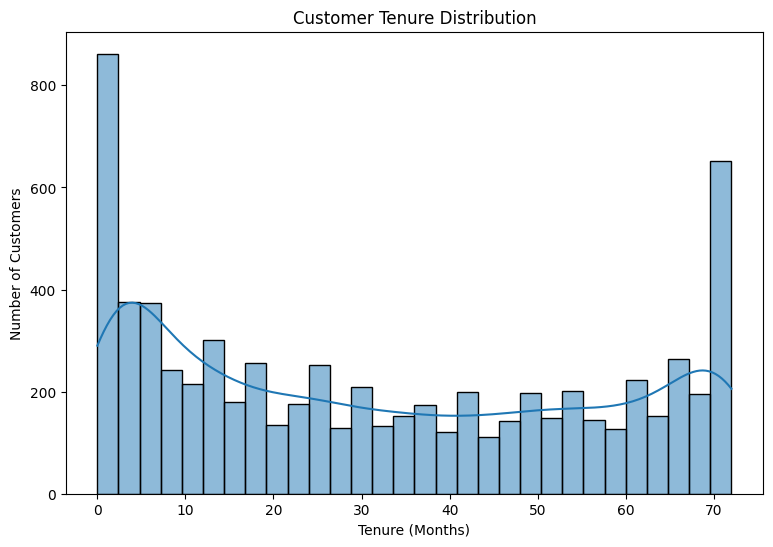

In [ ]:
plt.figure(figsize=(9,6))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Customer Tenure Distribution")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

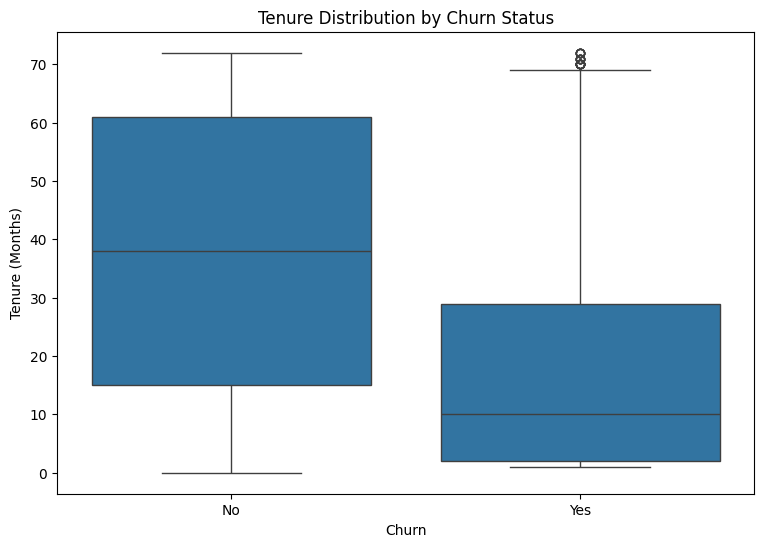

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df, x="Churn", y="tenure")

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

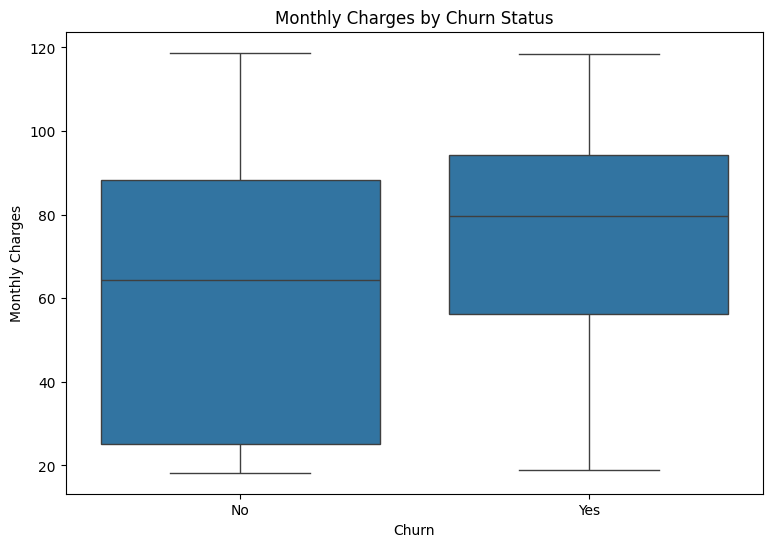

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print(df["TotalCharges"].isnull().sum())

11


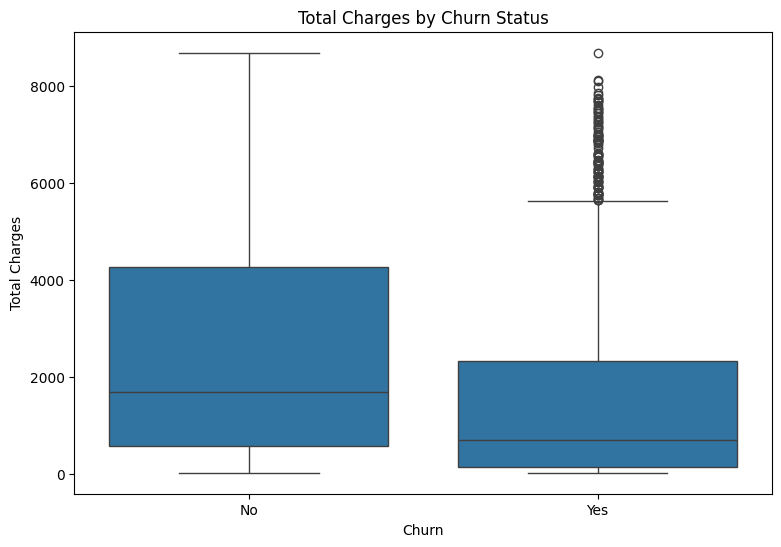

In [ ]:
plt.figure(figsize=(9,6))

sns.boxplot(data=df, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.show()

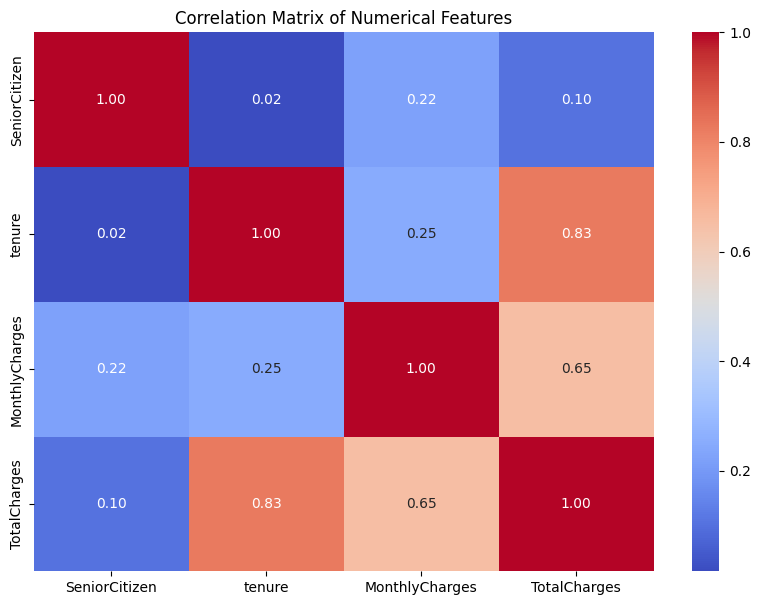

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df["TotalCharges"].dtype)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

float64
Missing TotalCharges: 11


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing TotalCharges after treatment:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after treatment: 0


In [ ]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

print("Missing TotalCharges after treatment:",
      df["TotalCharges"].isnull().sum())

Missing TotalCharges after treatment: 0


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Series([], dtype: int64)


In [ ]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (7043, 21)


In [ ]:
df = df.drop("customerID", axis=1)

print("Dataset shape:", df.shape)

Dataset shape: (7043, 20)


In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print(df["Churn"].dtype)

int64


In [ ]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [ ]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
print("\nTarget distribution (%):")
print(y.value_counts(normalize=True) * 100)


Target distribution (%):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5634, 19)
Testing set: (1409, 19)


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [ ]:
decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

In [ ]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

In [ ]:
gradient_boosting_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=42
    ))
])

In [ ]:
models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": gradient_boosting_pipeline
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [ ]:
predictions = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [ ]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
3,Gradient Boosting,0.806246,0.673540,0.524064,0.589474,0.843212
2,Random Forest,0.775018,0.597938,0.465241,0.523308,0.818704
1,Decision Tree,0.728886,0.489637,0.505348,0.497368,0.657266


In [ ]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    print("\n" + "=" * 60)
    print(name)
    print("=" * 60)

    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Churn", "Churn"]
    ))


Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.81      0.81      1035
       Churn       0.49      0.51      0.50       374

    accuracy                           0.73      1409
   macro avg       0.65      0.66      0.66      1409
weighted avg       0.73      0.73      0.73      1409


Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.47      0.52       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76

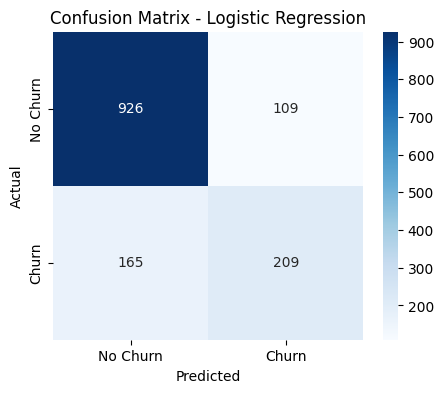

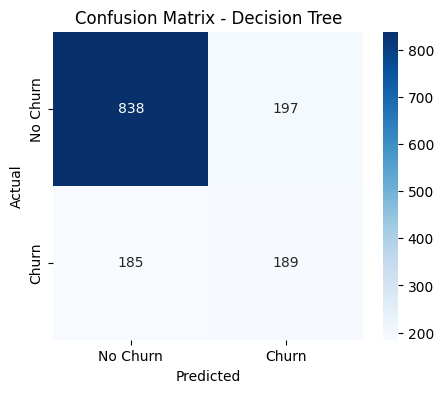

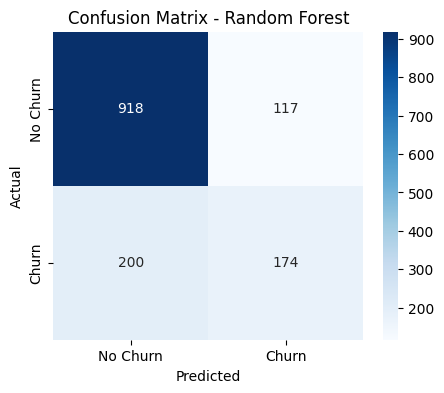

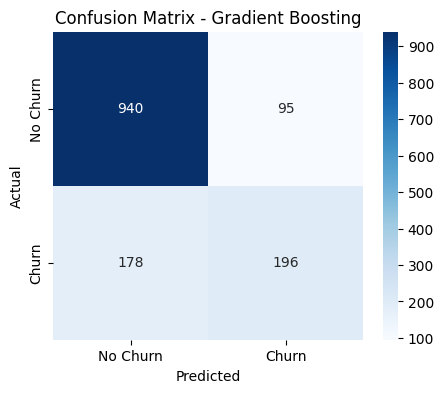

In [ ]:
for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

<Figure size 1000x600 with 0 Axes>

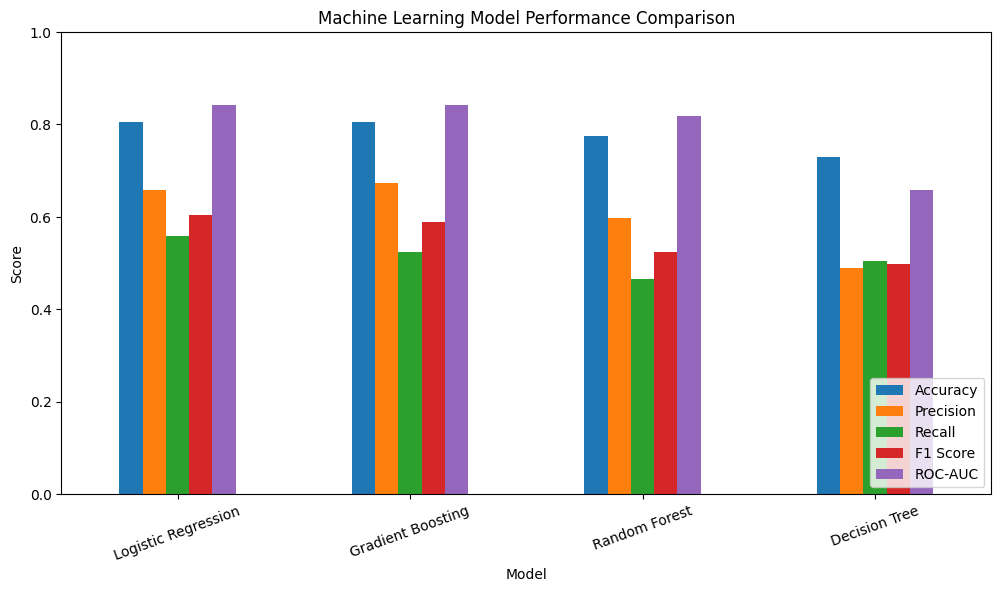

In [ ]:
plt.figure(figsize=(10, 6))

results_plot = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision"].mean(),
        "CV Recall": scores["test_recall"].mean(),
        "CV F1": scores["test_f1"].mean(),
        "CV ROC-AUC": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.sort_values(
    by="CV F1",
    ascending=False
)

,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.801919,0.652611,0.542475,0.591798,0.846038
3,Gradient Boosting,0.803517,0.660821,0.534448,0.590727,0.847879
2,Random Forest,0.785768,0.624714,0.484950,0.545748,0.820187
1,Decision Tree,0.730209,0.491957,0.505686,0.498631,0.658290


In [ ]:
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__solver": ["liblinear", "lbfgs"]
}

In [ ]:
logistic_grid = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

logistic_grid.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneServic...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__solver': ['liblinear', 'lbfgs']},
             scoring='f1', verbose=1)

In [ ]:
print("Best Logistic Regression Parameters:")
print(logistic_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(logistic_grid.best_score_)

Best Logistic Regression Parameters:
{'model__C': 100, 'model__solver': 'liblinear'}

Best Cross-Validation F1 Score:
0.5973782660853237


In [ ]:
rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [ ]:
rf_grid = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneServic...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model',
                                        RandomForestClassifier(n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 5, 10, 20],
                         'model__min_samples_leaf': [1, 2, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [100, 200, 300]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross-Validation F1 Score:
0.5845164967017358


In [ ]:
gb_param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_split": [2, 5, 10]
}

In [ ]:
gb_grid = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneServic...
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('model',
                                        GradientBoostingClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [2, 3, 4],
                         'model__min_samples_split': [2, 5, 10],
                         'model__n_estimators': [50, 100, 200]},
             scoring='f1', verbose=1)

In [ ]:
print("Best Gradient Boosting Parameters:")
print(gb_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(gb_grid.best_score_)

Best Gradient Boosting Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__min_samples_split': 10, 'model__n_estimators': 100}

Best Cross-Validation F1 Score:
0.5937184874181496


In [ ]:
tuned_models = {
    "Tuned Logistic Regression": logistic_grid.best_estimator_,
    "Tuned Random Forest": rf_grid.best_estimator_,
    "Tuned Gradient Boosting": gb_grid.best_estimator_
}

In [ ]:
tuned_results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Tuned Gradient Boosting,0.806955,0.670000,0.537433,0.596439,0.844610
0,Tuned Logistic Regression,0.800568,0.646688,0.548128,0.593343,0.840675
1,Tuned Random Forest,0.803407,0.664407,0.524064,0.585949,0.840910


In [ ]:
best_model = tuned_models["Tuned Gradient Boosting"]

y_prob = best_model.predict_proba(X_test)[:, 1]

print("First 10 churn probabilities:")
print(y_prob[:10])

First 10 churn probabilities:
[0.02272422 0.82041399 0.06412571 0.32149845 0.02418755 0.60267787
 0.47838621 0.09566839 0.01650918 0.35302116]


In [ ]:
thresholds = np.arange(0.20, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:

    y_threshold_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_threshold_pred,
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            y_test,
            y_threshold_pred
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1 Score,Accuracy
0,0.20,0.487616,0.842246,0.617647,0.723208
1,0.25,0.516239,0.807487,0.629823,0.748048
2,0.30,0.535849,0.759358,0.628319,0.761533
3,0.35,0.556962,0.705882,0.622642,0.772889
4,0.40,0.581281,0.631016,0.605128,0.781405
5,0.45,0.620690,0.577540,0.598338,0.794180
6,0.50,0.670000,0.537433,0.596439,0.806955
7,0.55,0.702128,0.441176,0.541872,0.801987
8,0.60,0.741935,0.368984,0.492857,0.798439
9,0.65,0.777778,0.299465,0.432432,0.791341


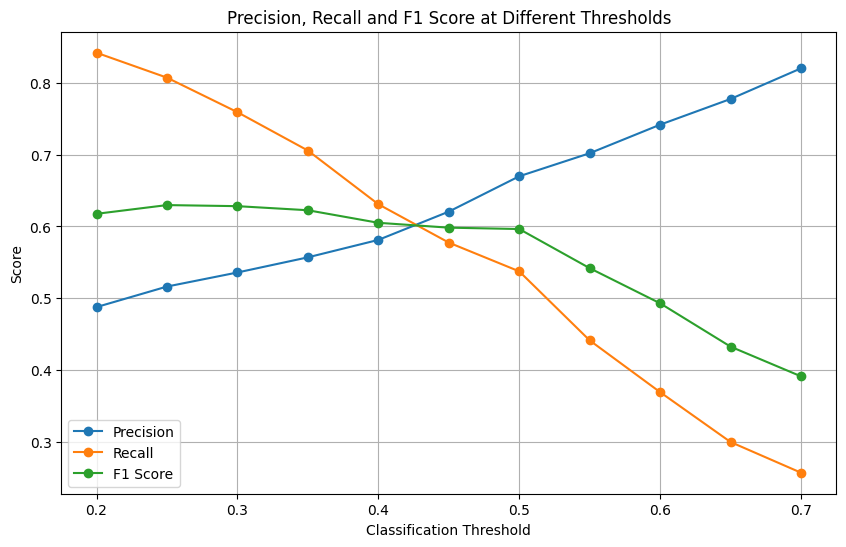

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score at Different Thresholds")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold Based on F1 Score:")
print(best_threshold_row)

Best Threshold Based on F1 Score:
Threshold    0.250000
Precision    0.516239
Recall       0.807487
F1 Score     0.629823
Accuracy     0.748048
Name: 1, dtype: float64


In [ ]:
best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", best_threshold)

Selected threshold: 0.25


In [ ]:
y_optimized = (
    y_prob >= best_threshold
).astype(int)

print(
    classification_report(
        y_test,
        y_optimized,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.81      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



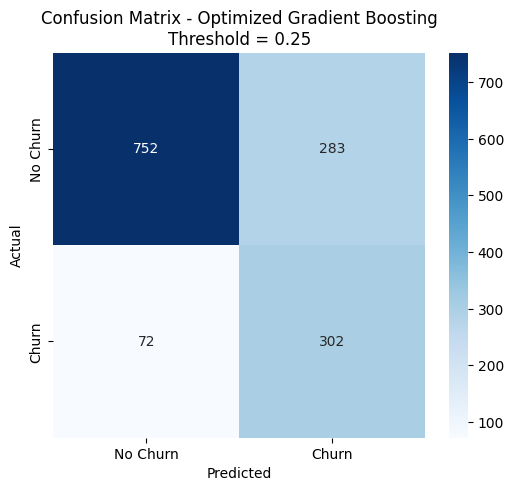

In [ ]:
cm = confusion_matrix(
    y_test,
    y_optimized
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title(
    f"Confusion Matrix - Optimized Gradient Boosting\n"
    f"Threshold = {best_threshold:.2f}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
default_pred = (y_prob >= 0.50).astype(int)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Default Threshold (0.50)": [
        accuracy_score(y_test, default_pred),
        precision_score(y_test, default_pred),
        recall_score(y_test, default_pred),
        f1_score(y_test, default_pred)
    ],
    "Optimized Threshold": [
        accuracy_score(y_test, y_optimized),
        precision_score(y_test, y_optimized),
        recall_score(y_test, y_optimized),
        f1_score(y_test, y_optimized)
    ]
})

threshold_comparison

,Metric,Default Threshold (0.50),Optimized Threshold
0,Accuracy,0.806955,0.748048
1,Precision,0.670000,0.516239
2,Recall,0.537433,0.807487
3,F1 Score,0.596439,0.629823


In [ ]:
# Extract fitted preprocessing pipeline
fitted_preprocessor = best_model.named_steps["preprocessor"]

# Extract fitted Gradient Boosting model
fitted_model = best_model.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get feature importance
feature_importance = fitted_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
36,cat__Contract_Month-to-month,0.381496
1,num__tenure,0.138612
3,num__TotalCharges,0.087478
16,cat__InternetService_Fiber optic,0.086544
2,num__MonthlyCharges,0.076813
18,cat__OnlineSecurity_No,0.068417
43,cat__PaymentMethod_Electronic check,0.044394
27,cat__TechSupport_No,0.037955
40,cat__PaperlessBilling_Yes,0.011710
12,cat__MultipleLines_No,0.010198


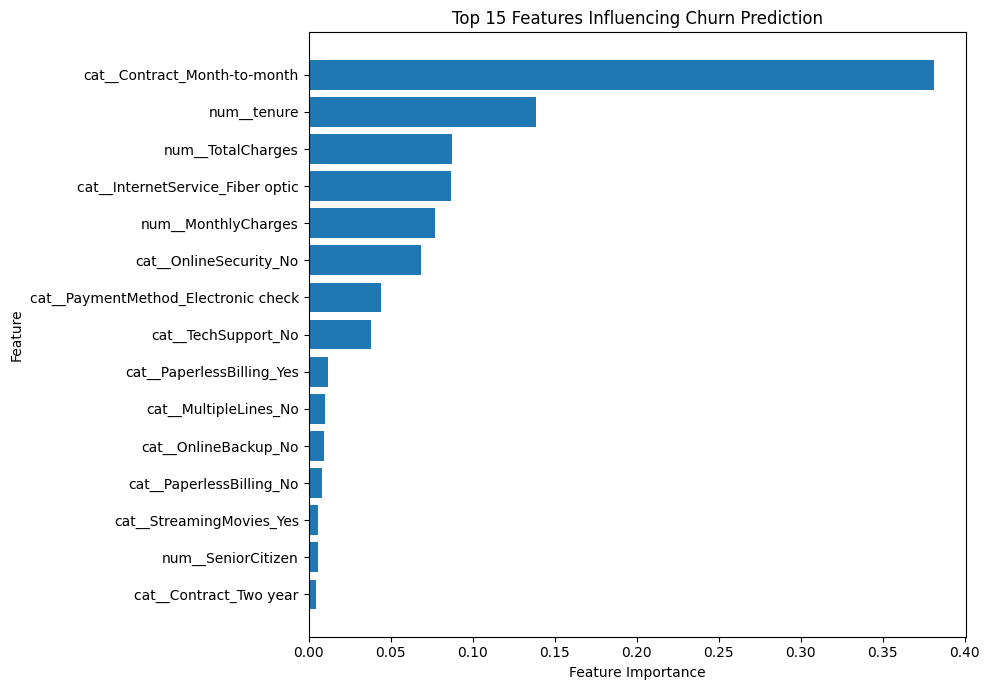

In [ ]:
top_features = importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features Influencing Churn Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [ ]:
y_prob

array([0.02272422, 0.82041399, 0.06412571, ..., 0.10566272, 0.01706787,
       0.00991741])

In [ ]:
risk_analysis = X_test.copy()

risk_analysis["Actual_Churn"] = y_test
risk_analysis["Churn_Probability"] = y_prob

In [ ]:
risk_analysis["Predicted_Churn"] = y_optimized

In [ ]:
def risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.60:
        return "Medium Risk"
    else:
        return "High Risk"

risk_analysis["Risk_Level"] = (
    risk_analysis["Churn_Probability"]
    .apply(risk_category)
)

In [ ]:
risk_analysis["Risk_Level"].value_counts()

,count
Risk_Level,
Low Risk,879
Medium Risk,344
High Risk,186


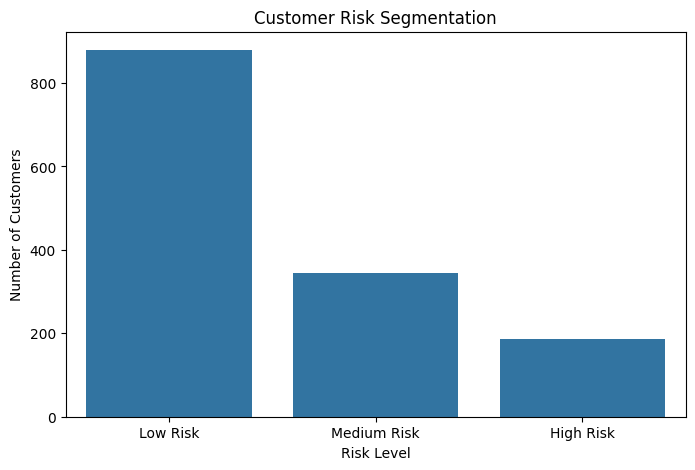

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=risk_analysis,
    x="Risk_Level",
    order=["Low Risk", "Medium Risk", "High Risk"]
)

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
high_risk_customers = risk_analysis.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk_customers[
    [
        "Churn_Probability",
        "Risk_Level",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "InternetService"
    ]
].head(20)

,Churn_Probability,Risk_Level,Contract,tenure,MonthlyCharges,InternetService
6623,0.929993,High Risk,Month-to-month,1,76.45,Fiber optic
2464,0.920090,High Risk,Month-to-month,1,77.15,Fiber optic
4585,0.913038,High Risk,Month-to-month,1,85.05,Fiber optic
3380,0.910494,High Risk,Month-to-month,1,95.10,Fiber optic
6866,0.909022,High Risk,Month-to-month,1,95.45,Fiber optic
2631,0.889743,High Risk,Month-to-month,7,99.25,Fiber optic
2246,0.889184,High Risk,Month-to-month,1,102.45,Fiber optic
6748,0.886531,High Risk,Month-to-month,1,85.00,Fiber optic
2194,0.884067,High Risk,Month-to-month,1,79.50,Fiber optic
5826,0.880370,High Risk,Month-to-month,1,79.35,Fiber optic


In [ ]:
risk_summary = risk_analysis.groupby(
    "Risk_Level"
).agg({
    "Churn_Probability": "mean",
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "TotalCharges": "mean"
})

risk_summary

,Churn_Probability,tenure,MonthlyCharges,TotalCharges
Risk_Level,,,,
High Risk,0.743679,6.010753,79.225538,537.118817
Low Risk,0.094214,42.050057,57.699261,2739.660609
Medium Risk,0.445560,20.026163,72.231395,1737.917878


In [ ]:
risk_churn_rate = risk_analysis.groupby(
    "Risk_Level"
)["Actual_Churn"].mean() * 100

print("Actual churn rate by predicted risk level:")
print(risk_churn_rate)

Actual churn rate by predicted risk level:
Risk_Level
High Risk      74.193548
Low Risk       10.238908
Medium Risk    42.441860
Name: Actual_Churn, dtype: float64


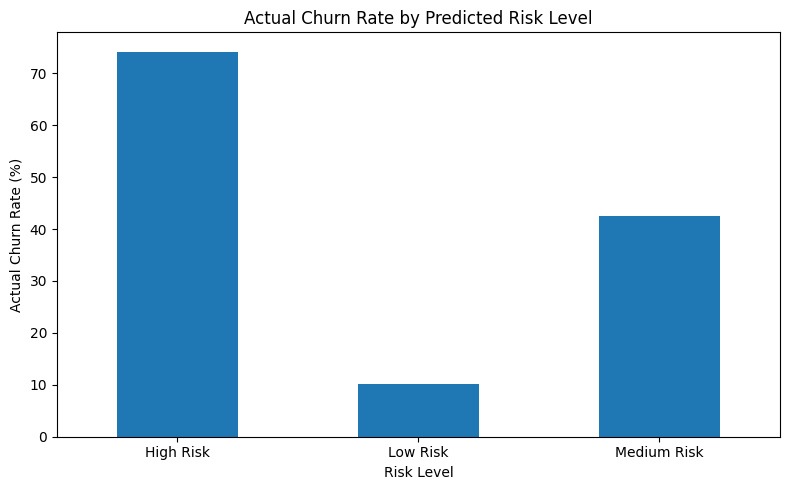

In [ ]:
plt.figure(figsize=(8, 5))

risk_churn_rate.plot(
    kind="bar"
)

plt.title("Actual Churn Rate by Predicted Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Actual Churn Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

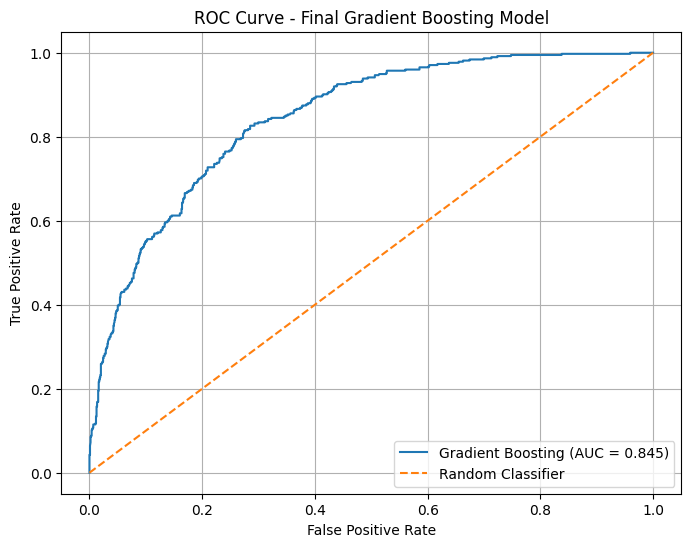

In [ ]:
from sklearn.metrics import roc_curve, auc

# Default 0.50 probability predictions
y_prob_final = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob_final
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Gradient Boosting (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Gradient Boosting Model")
plt.legend()
plt.grid(True)

plt.show()

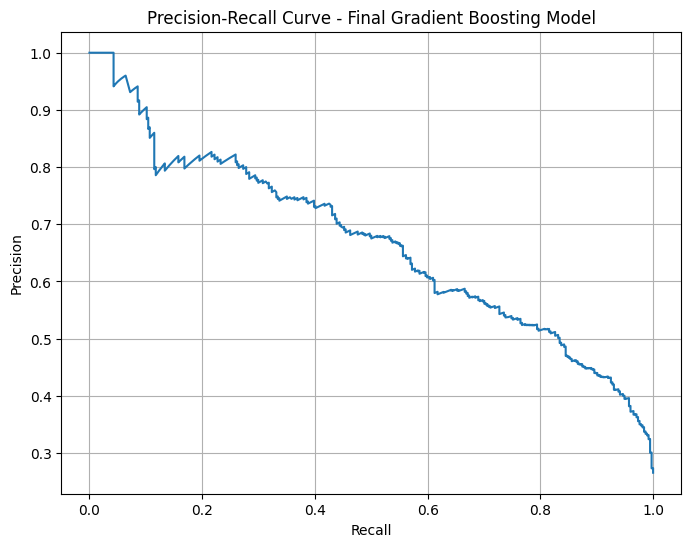

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob_final
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final Gradient Boosting Model")
plt.grid(True)

plt.show()

In [ ]:
final_default_pred = (y_prob_final >= 0.50).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_default_pred),
    "Precision": precision_score(y_test, final_default_pred),
    "Recall": recall_score(y_test, final_default_pred),
    "F1 Score": f1_score(y_test, final_default_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final)
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Score"]
)

final_metrics_df

,Metric,Score
0,Accuracy,0.806955
1,Precision,0.670000
2,Recall,0.537433
3,F1 Score,0.596439
4,ROC-AUC,0.844610


In [ ]:
final_default_pred = (y_prob_final >= 0.50).astype(int)

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_default_pred),
    "Precision": precision_score(y_test, final_default_pred),
    "Recall": recall_score(y_test, final_default_pred),
    "F1 Score": f1_score(y_test, final_default_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob_final)
}

final_metrics_df = pd.DataFrame(
    final_metrics.items(),
    columns=["Metric", "Score"]
)

final_metrics_df

,Metric,Score
0,Accuracy,0.806955
1,Precision,0.670000
2,Recall,0.537433
3,F1 Score,0.596439
4,ROC-AUC,0.844610


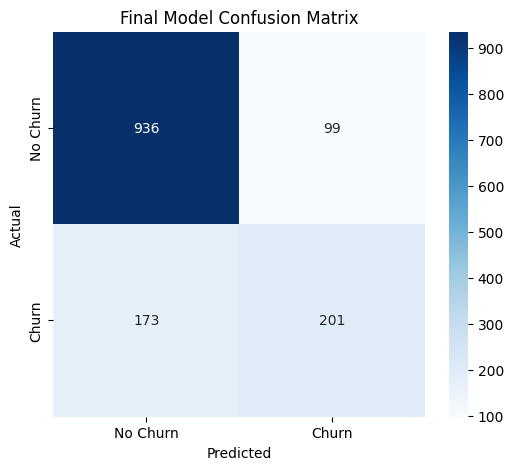

In [ ]:
final_cm = confusion_matrix(
    y_test,
    final_default_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

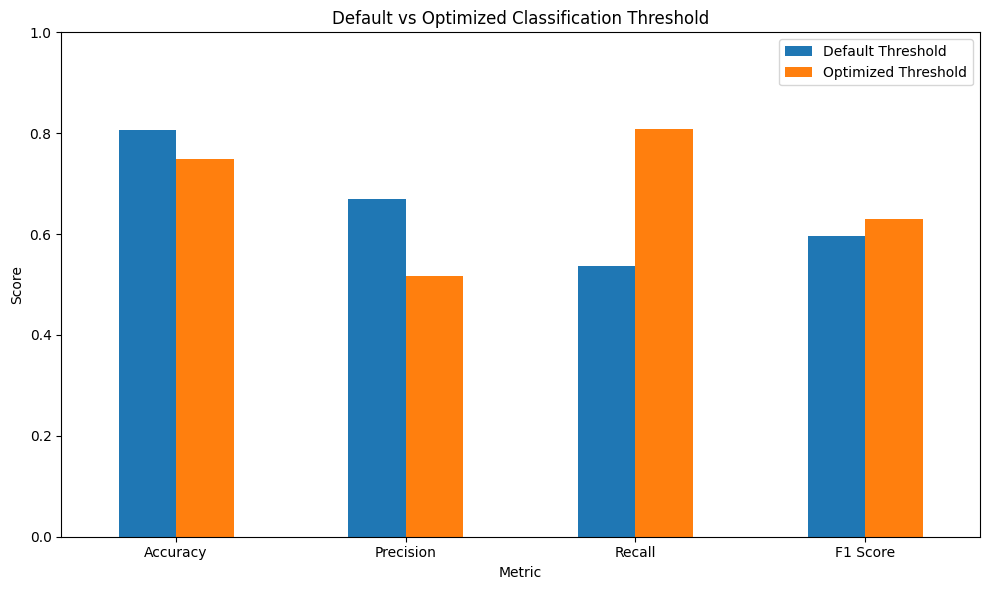

In [ ]:
comparison_plot = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Default Threshold": [
        accuracy_score(y_test, default_pred),
        precision_score(y_test, default_pred),
        recall_score(y_test, default_pred),
        f1_score(y_test, default_pred)
    ],
    "Optimized Threshold": [
        accuracy_score(y_test, y_optimized),
        precision_score(y_test, y_optimized),
        recall_score(y_test, y_optimized),
        f1_score(y_test, y_optimized)
    ]
})

comparison_plot.set_index("Metric").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Default vs Optimized Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def predict_customer_risk(customer_data):

    customer_df = pd.DataFrame([customer_data])

    probability = best_model.predict_proba(customer_df)[0, 1]

    if probability < 0.30:
        risk = "Low Risk"
        recommendation = "Continue regular customer engagement."

    elif probability < 0.60:
        risk = "Medium Risk"
        recommendation = "Consider personalized engagement and retention offers."

    else:
        risk = "High Risk"
        recommendation = "Prioritize customer retention intervention."

    return {
        "Churn Probability": round(probability, 4),
        "Risk Level": risk,
        "Recommendation": recommendation
    }

In [ ]:
sample_customer = X_test.iloc[0].to_dict()

prediction = predict_customer_risk(sample_customer)

prediction

{'Churn Probability': np.float64(0.0227),
 'Risk Level': 'Low Risk',
 'Recommendation': 'Continue regular customer engagement.'}